# 1 month salt budget test for panant-01

In [1]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [2]:
lat_slice = slice(-79,-59)

# Importing data
paths_2 = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia-expt-c085baf0/output000/ocean/ocean.nc'))
paths_1 = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia-expt-c085baf0/output000/ocean/ocean_month.nc'))

In [3]:
paths_1

array(['/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia-expt-c085baf0/output000/ocean/ocean_month.nc'],
      dtype='<U103')

In [4]:
# Time variant variables
def preprocess_1(ds):
    ds = ds[['pme_river','runoff','evap',]].sel(yt_ocean=lat_slice)
    return ds

def preprocess_2(ds):
    ds = ds[['salt','salt_advection','salt_submeso','salt_tendency','salt_vdiffuse_impl','salt_nonlocal_KPP','salt_rivermix','salt_eta_smooth']].sel(yt_ocean=lat_slice)
    return ds

#data_1 = xr.open_mfdataset(paths_1, preprocess = preprocess_1, chunks = 'auto')
data_2 = xr.open_mfdataset(paths_2, preprocess = preprocess_2, chunks = 'auto',decode_times=False)

In [5]:
data_2

<xarray.Dataset> Size: 3GB
Dimensions:             (time: 1, st_ocean: 75, yt_ocean: 460, xt_ocean: 3600)
Coordinates:
  * time                (time) float64 8B 15.5
  * st_ocean            (st_ocean) float64 600B 0.5413 1.681 ... 5.709e+03
  * yt_ocean            (yt_ocean) float64 4kB -79.0 -78.95 ... -59.08 -59.03
  * xt_ocean            (xt_ocean) float64 29kB -279.9 -279.8 ... 79.85 79.95
Data variables:
    salt                (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_advection      (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_submeso        (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_tendency       (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_vdiffuse_impl  (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_nonlocal_KPP   (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_rivermix       (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_eta_smooth     (time, yt_ocean, xt_ocean) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
Attributes:
    filename:   ocean.nc
    title:      ACCESS-OM2-01
    grid_type:  mosaic
    grid_tile:  1
    history:    20260223T0208Z: /g/data/ik11/inputs/access-om2/bin/mppnccombi...

In [6]:
lhs_salt = {
    'salt_tendency': data_2.salt_tendency
}

rhs_salt = {
    # Advection
    'advection': data_2.salt_advection,
    'submeso': data_2.salt_submeso,

    # Diffusion / mixing + Surface & boundary forcing
    'vertical_diffusion': data_2.salt_vdiffuse_impl, # this includes surface salt flux
    'neutral_diffusion': data_2.salt_nonlocal_KPP,
    'river_mix': data_2.salt_rivermix,
    'eta_smooth': data_2.salt_eta_smooth,
}

At the moment taking `time`=0 to just look at first month - but I'm unsure this is still giving me the right evolution over time that I am looking for.

ValueError: 'st_ocean' not found in array dimensions ('time', 'yt_ocean', 'xt_ocean')

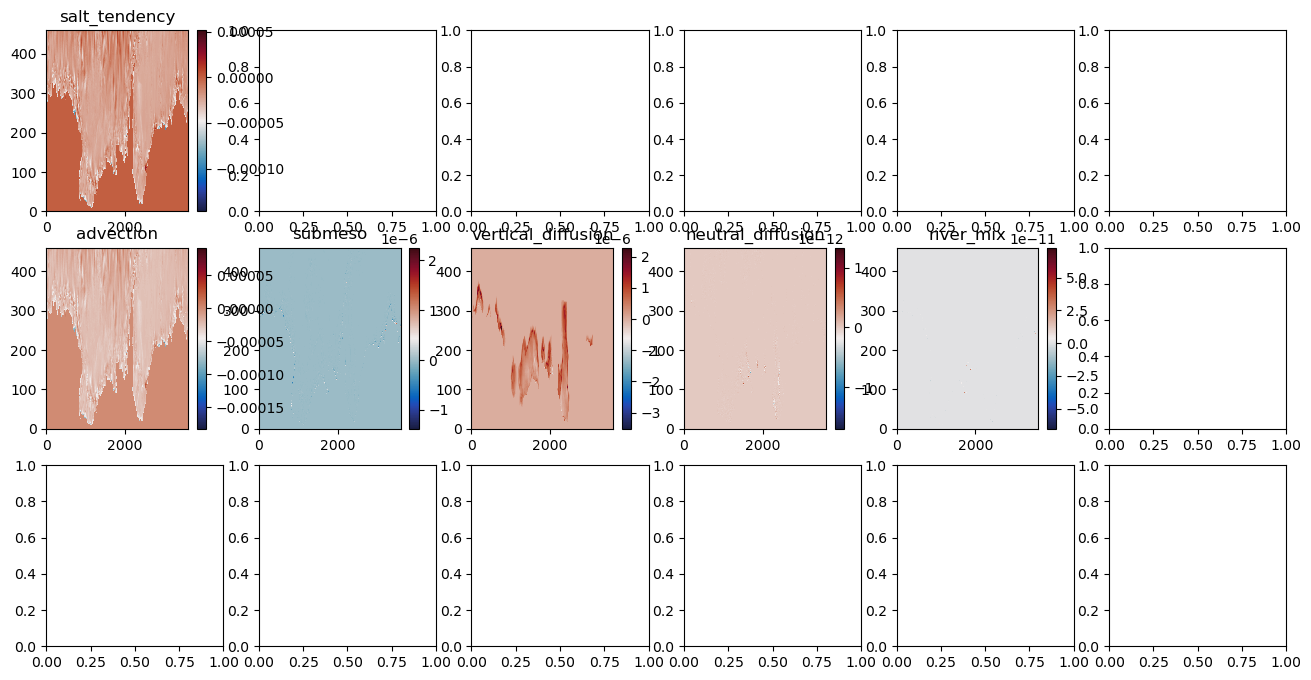

In [7]:
zdim = 'st_ocean'  # MOM5 vertical grid dimension

fig, ax = plt.subplots(
    figsize=(16, 8),
    nrows=3,
    ncols=max(len(lhs_salt), len(rhs_salt))
)
ax = ax.reshape(3, -1)  # flatten for consistent indexing

# -----------------------
# LHS terms
# -----------------------
for i, (name, da) in enumerate(lhs_salt.items()):
    da2d = da.sum(zdim).squeeze()
    if 'time' in da2d.dims:
        da2d = da2d.isel(time=0)
    da2d = da2d.compute()
    im = ax[0, i].pcolormesh(da2d, cmap=cm.cm.balance,)
    plt.colorbar(im, ax=ax[0, i])
    ax[0, i].set_title(name)

# -----------------------
# RHS terms
# -----------------------
for i, (name, da) in enumerate(rhs_salt.items()):
    da2d = da.sum(zdim).squeeze()
    if 'time' in da2d.dims:
        da2d = da2d.isel(time=0)
    da2d = da2d.compute()
    im = ax[1, i].pcolormesh(da2d,cmap=cm.cm.balance,)
    plt.colorbar(im, ax=ax[1, i])
    ax[1, i].set_title(name)

# -----------------------
# Closure residual
# -----------------------
lhs_total = data_2.salt_tendency

rhs_total = (
    data_2.salt_advection
    + data_2.salt_submeso
    + data_2.salt_vdiffuse_impl
    + data_2.salt_nonlocal_KPP
    + data_2.salt_rivermix
    + data_2.salt_eta_smooth
)

residual = (lhs_total - rhs_total).sum(zdim).squeeze()

if 'time' in residual.dims:
    residual = residual.isel(time=0)

residual = residual.compute()
vmax = np.abs(residual).max()

im = ax[2, 0].pcolormesh(
    residual, cmap=cm.cm.balance, vmin=-vmax, vmax=vmax
)
plt.colorbar(im, ax=ax[2, 0])
ax[2, 0].set_title('closure residual')


# -----------------------
# Row labels
# -----------------------
ax[0, 0].set_ylabel('LHS (tendency)')
ax[1, 0].set_ylabel('RHS (all process tendencies)')
ax[2, 0].set_ylabel('tendency − Σ(processes)')

plt.tight_layout()


#### Checking if we have closure:   
We are told that for the budget to be considered “closed” the difference between the LHS and RHS should be approximately 12 orders of magnitude smaller than the contributing terms. 

In [7]:
closure = lhs_total - rhs_total

In [8]:
closure.max().compute()

<xarray.DataArray ()> Size: 4B
array(2.2695788e-08, dtype=float32)

In [9]:
closure.min().compute()

<xarray.DataArray ()> Size: 4B
array(-1.877936e-08, dtype=float32)

In [15]:
closure

<xarray.DataArray (time: 2, z_l: 75, yh: 460, xh: 3600)> Size: 994MB
dask.array<sub, shape=(2, 75, 460, 3600), dtype=float32, chunksize=(2, 31, 242, 1030), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 16B 1991-03-16 12:00:00 1991-04-16 00:00:00
  * z_l      (z_l) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * yh       (yh) float64 4kB -79.0 -78.95 -78.91 ... -59.14 -59.08 -59.03
  * xh       (xh) float64 29kB -279.9 -279.8 -279.7 -279.6 ... 79.75 79.85 79.95

In [14]:
# Note residual = (lhs_total - rhs_total).sum(zdim).squeeze()
residual

<xarray.DataArray (yh: 460, xh: 3600)> Size: 7MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)
Coordinates:
  * yh       (yh) float64 4kB -79.0 -78.95 -78.91 ... -59.14 -59.08 -59.03
  * xh       (xh) float64 29kB -279.9 -279.8 -279.7 -279.6 ... 79.75 79.85 79.95
    time     object 8B 1991-03-16 12:00:00

In [11]:
residual.max().compute()

<xarray.DataArray ()> Size: 8B
array(0.)
Coordinates:
    time     object 8B 1991-03-16 12:00:00

In [12]:
residual.min().compute()

<xarray.DataArray ()> Size: 8B
array(0.)
Coordinates:
    time     object 8B 1991-03-16 12:00:00

In [13]:
# testing individual diagnostics
tendency = data_2.salt_tendency
advection = data_2.salt_advection
submeso = data_2.salt_submeso
diff_1 = data_2.salt_vdiffuse_impl
diff_2 = data_2.salt_nonlocal_KPP
diff_3 = data_2.salt_rivermix
diff_4 = data_2.salt_eta_smooth

In [ ]:
#residual = (lhs_total - rhs_total).sum(zdim).squeeze()

## Checking ice thickness issue using old experiments

In [21]:
sit_map_C = xr.open_dataarray('/g/data/g40/kc5856/thesis_figures/data_files/ice_thickness_map_cont_Pan01.nc', chunks = 'auto')
sit_map_M = xr.open_dataarray('/g/data/g40/kc5856/thesis_figures/data_files/ice_thickness_map_melt_Pan01.nc', chunks = 'auto')

In [23]:
sit_map_C.max().load()

<xarray.DataArray 'sithick' ()> Size: 4B
array(2.421659, dtype=float32)

In [24]:
sit_map_C.min().load()

<xarray.DataArray 'sithick' ()> Size: 4B
array(0., dtype=float32)

In [25]:
sit_map_M.max().load()

<xarray.DataArray 'sithick' ()> Size: 4B
array(2.4113848, dtype=float32)